In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================
# PHASE 1: DATA COLLECTION & PREPARATION
# ============================================

In [78]:
# Load the dataset
df = pd.read_csv('diabetes.csv')
#Kaggle link: https://www.kaggle.com/code/paultimothymooney/predict-diabetes-from-medical-records/input
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe()}")

DATASET OVERVIEW
Dataset Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure         

In [79]:
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("No missing values found!")


MISSING VALUES
Series([], dtype: int64)
No missing values found!


In [80]:
# Check class imbalance
print("\n" + "="*70)
print("TARGET VARIABLE ANALYSIS")
print("="*70)
class_dist = df['Outcome'].value_counts()
class_pct = df['Outcome'].value_counts(normalize=True) * 100
print(f"\nClass 0 (No Diabetes): {class_dist[0]} ({class_pct[0]:.2f}%)")
print(f"Class 1 (Diabetes):    {class_dist[1]} ({class_pct[1]:.2f}%)")
print(f"Imbalance Ratio: {class_dist[0] / class_dist[1]:.2f}:1")
print("\n⚠️  Moderate class imbalance detected - using stratified sampling")


TARGET VARIABLE ANALYSIS

Class 0 (No Diabetes): 500 (65.10%)
Class 1 (Diabetes):    268 (34.90%)
Imbalance Ratio: 1.87:1

⚠️  Moderate class imbalance detected - using stratified sampling


In [81]:
# Check for duplicates
print("\n" + "="*50)
print("DUPLICATE ROWS")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")


DUPLICATE ROWS
Number of duplicate rows: 0


In [82]:
# Check class distribution
print("\n" + "="*50)
print("TARGET VARIABLE DISTRIBUTION")
print("="*50)
print(df['Outcome'].value_counts())
print(f"\nClass Balance:\n{df['Outcome'].value_counts(normalize=True)}")


TARGET VARIABLE DISTRIBUTION
Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


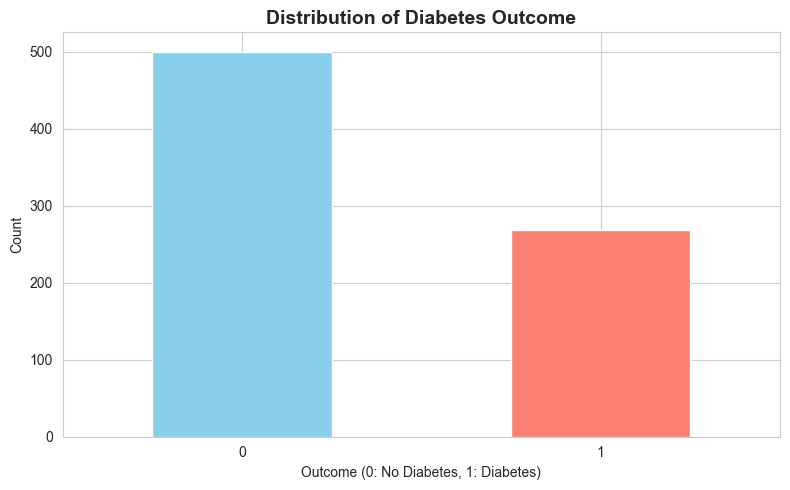

In [83]:
# Visualize class distribution
plt.figure(figsize=(8, 5))
df['Outcome'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Diabetes Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outcome_distribution.png', dpi=300)
plt.show()

# ============================================
# DATA QUALITY CHECKS & CLEANING
# ============================================

In [84]:
# Check for zeros in columns where zero might be invalid
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        zero_pct = (zero_count / len(df)) * 100
        print(f"{col}: {zero_count} zeros ({zero_pct:.2f}%)")

Glucose: 5 zeros (0.65%)
BloodPressure: 35 zeros (4.56%)
SkinThickness: 227 zeros (29.56%)
Insulin: 374 zeros (48.70%)
BMI: 11 zeros (1.43%)


In [85]:
# Replace zeros with NaN for specific columns (biological impossibility)
critical_columns = ['Glucose', 'BloodPressure', 'BMI']
for col in critical_columns:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

In [86]:
# Impute missing values with median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Imputed {col} with median value")

Imputed Glucose with median value
Imputed BloodPressure with median value
Imputed BMI with median value


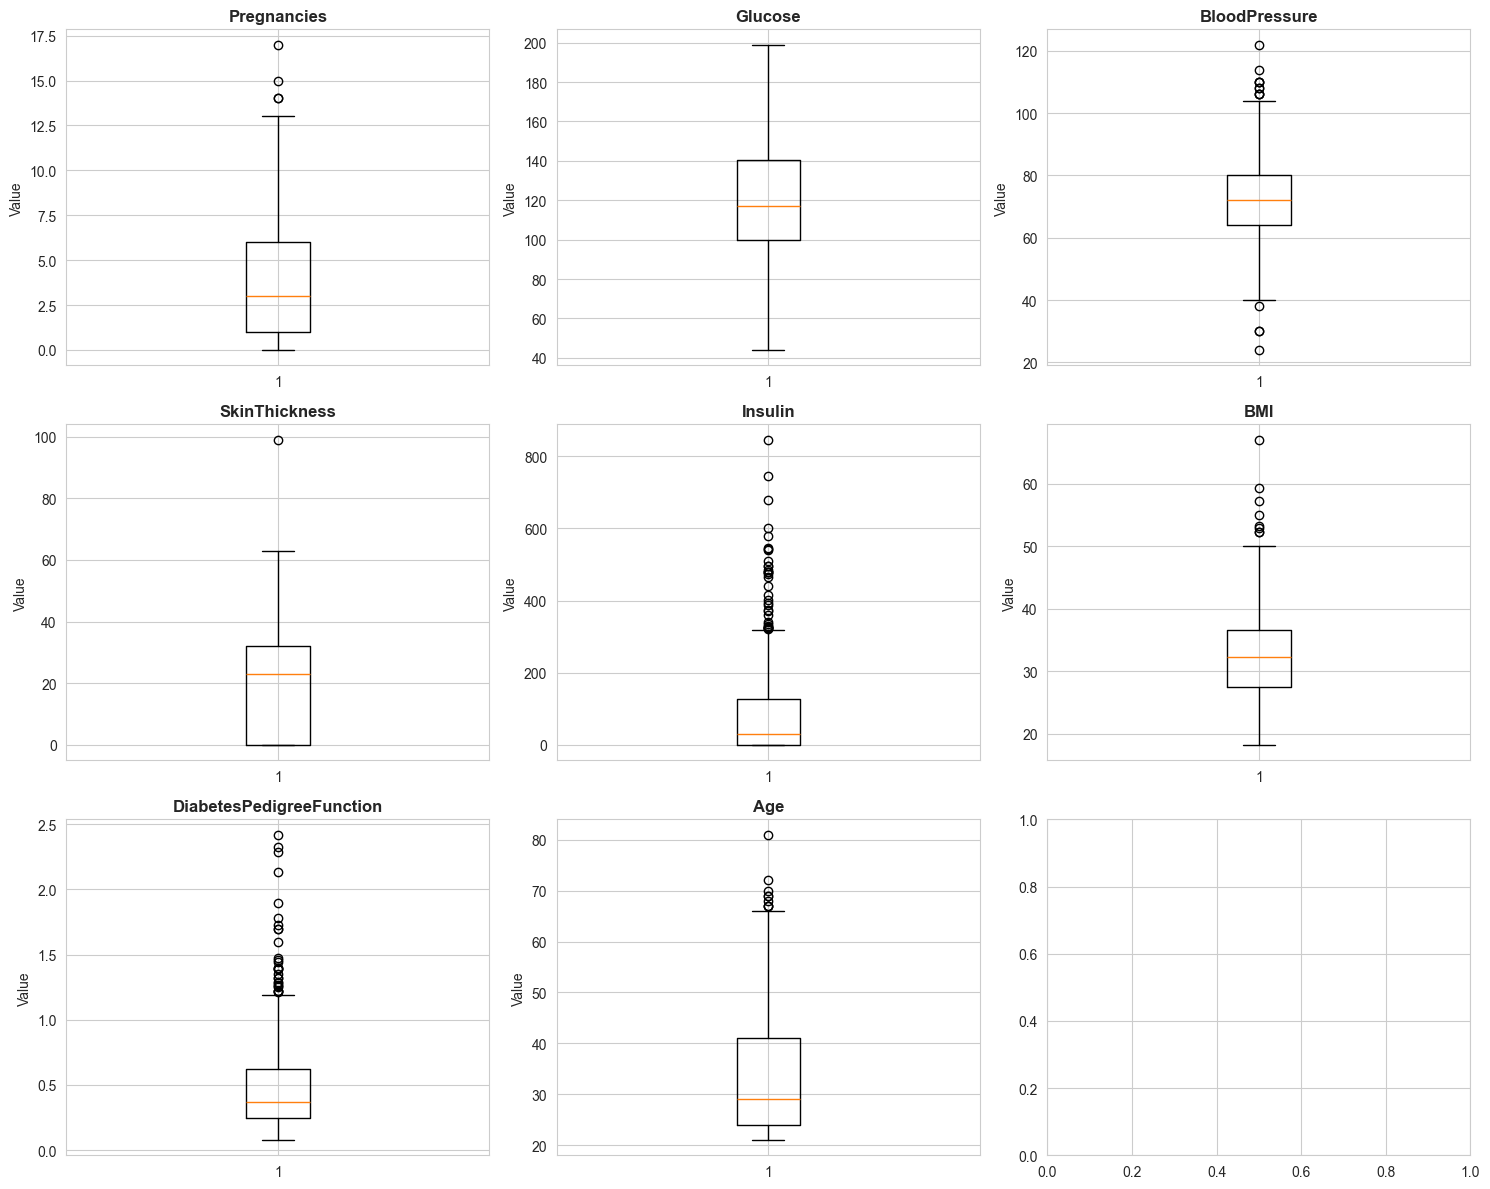

In [87]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for idx, col in enumerate(numeric_columns):
    if idx < len(axes):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Value')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=300)
plt.show()

In [88]:


# Check for outliers using IQR method
print("\n" + "="*50)
print("OUTLIER DETECTION")
print("="*50)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns.remove('Outcome')  # Remove target variable

outlier_summary = []
for col in numeric_columns:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary.append({
        'Column': col,
        'Outliers': n_outliers,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })
    print(f"{col}: {n_outliers} outliers detected")


OUTLIER DETECTION
Pregnancies: 4 outliers detected
Glucose: 0 outliers detected
BloodPressure: 14 outliers detected
SkinThickness: 1 outliers detected
Insulin: 34 outliers detected
BMI: 8 outliers detected
DiabetesPedigreeFunction: 29 outliers detected
Age: 9 outliers detected


In [89]:
# ============================================
# OUTLIER TREATMENT - WINSORIZATION
# ============================================

from scipy.stats.mstats import winsorize

print("\n" + "="*50)
print("OUTLIER TREATMENT (WINSORIZATION)")
print("="*50)

# Apply winsorization (cap at 5th and 95th percentiles)
for col in numeric_columns:
    before_max = df[col].max()
    before_min = df[col].min()
    
    # Winsorize: limit extreme values to 5th and 95th percentiles
    df[col] = winsorize(df[col], limits=[0.05, 0.05])
    
    after_max = df[col].max()
    after_min = df[col].min()
    
    if before_max != after_max or before_min != after_min:
        print(f"✓ {col}: Range changed from [{before_min:.2f}, {before_max:.2f}] to [{after_min:.2f}, {after_max:.2f}]")

print("\n✓ Winsorization complete: Extreme values capped at 5th/95th percentiles")


OUTLIER TREATMENT (WINSORIZATION)
✓ Pregnancies: Range changed from [0.00, 17.00] to [0.00, 10.00]
✓ Glucose: Range changed from [44.00, 199.00] to [80.00, 181.00]
✓ BloodPressure: Range changed from [24.00, 122.00] to [52.00, 90.00]
✓ SkinThickness: Range changed from [0.00, 99.00] to [0.00, 44.00]
✓ Insulin: Range changed from [0.00, 846.00] to [0.00, 293.00]
✓ BMI: Range changed from [18.20, 67.10] to [22.20, 44.50]
✓ DiabetesPedigreeFunction: Range changed from [0.08, 2.42] to [0.14, 1.14]
✓ Age: Range changed from [21.00, 81.00] to [21.00, 58.00]

✓ Winsorization complete: Extreme values capped at 5th/95th percentiles


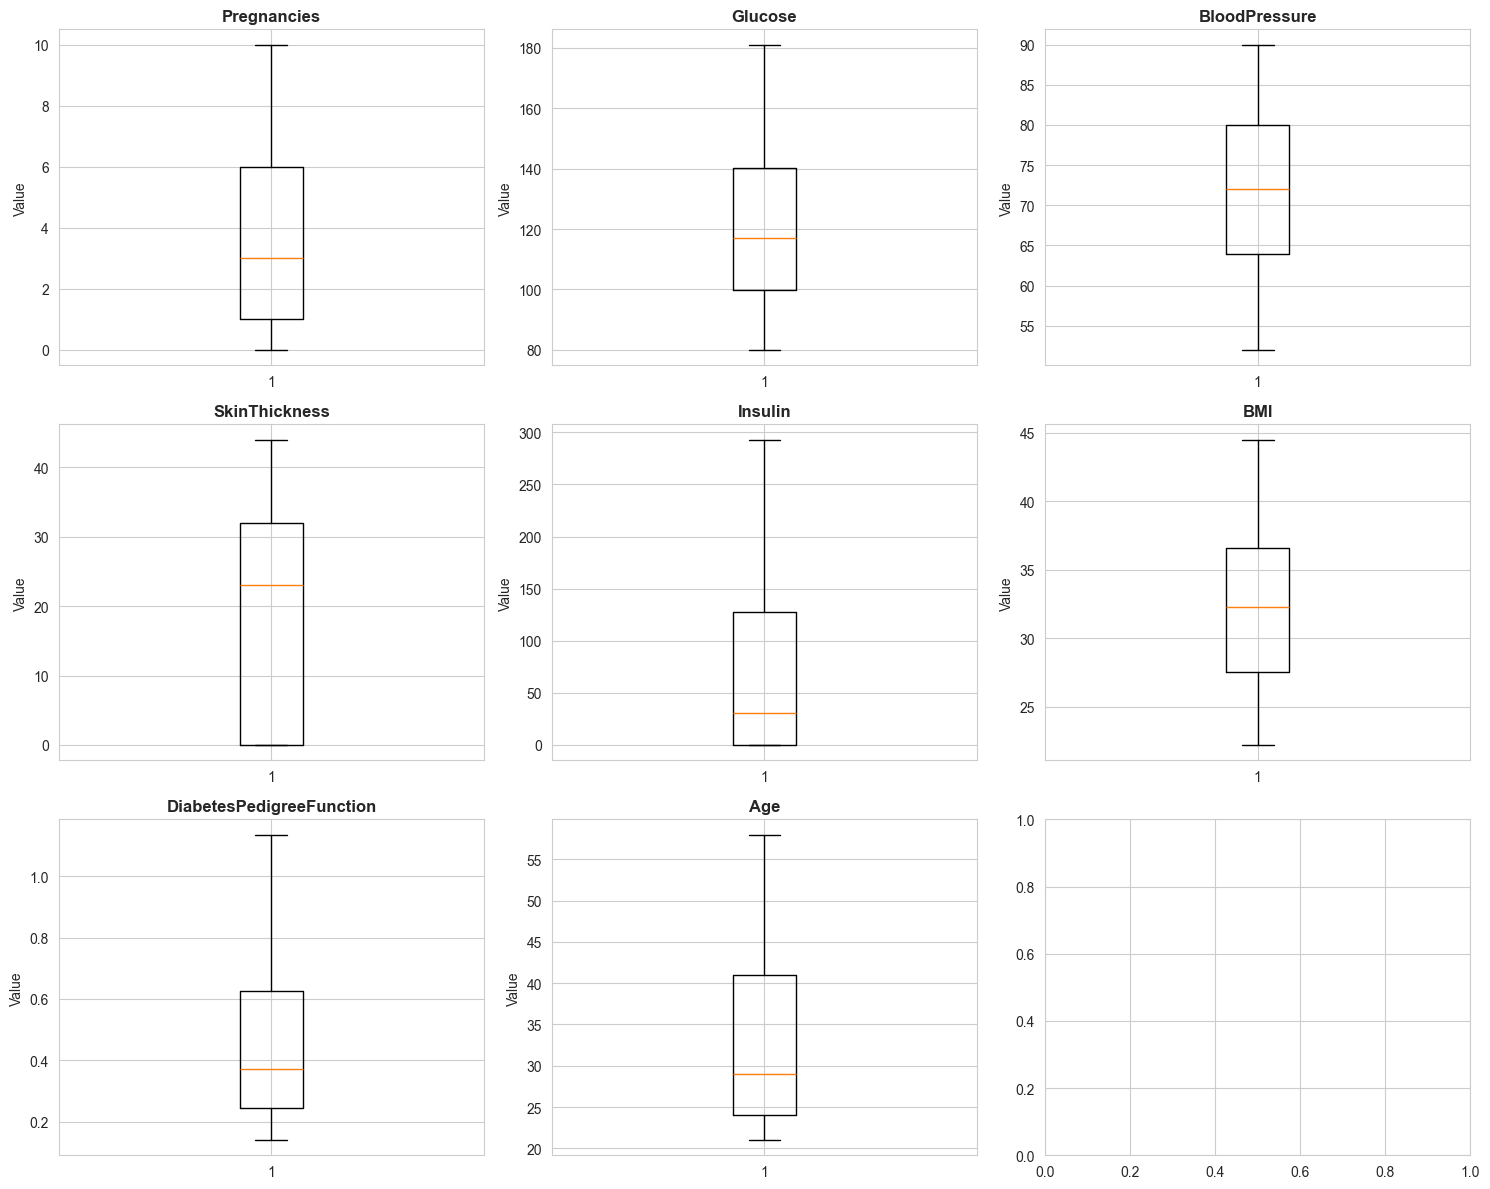

In [90]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for idx, col in enumerate(numeric_columns):
    if idx < len(axes):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Value')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=300)
plt.show()


# EXPLORATORY DATA ANALYSIS


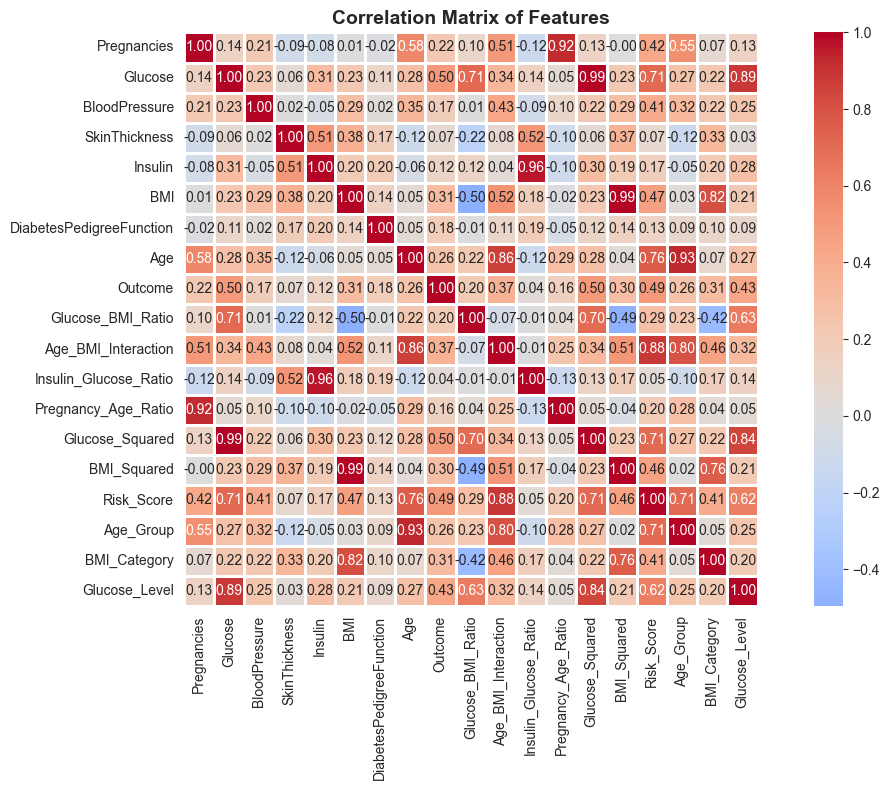

In [106]:
# Correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

In [107]:
# Feature correlation with target
target_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print("\nCorrelation with Outcome (Diabetes):")
print(target_corr)


Correlation with Outcome (Diabetes):
Outcome                     1.000000
Glucose                     0.495905
Glucose_Squared             0.495753
Risk_Score                  0.494801
Glucose_Level               0.432737
Age_BMI_Interaction         0.370707
BMI                         0.308463
BMI_Category                0.308193
BMI_Squared                 0.298434
Age_Group                   0.263667
Age                         0.260498
Pregnancies                 0.219720
Glucose_BMI_Ratio           0.201475
DiabetesPedigreeFunction    0.183589
BloodPressure               0.171301
Pregnancy_Age_Ratio         0.156344
Insulin                     0.122785
SkinThickness               0.067962
Insulin_Glucose_Ratio       0.040403
Name: Outcome, dtype: float64


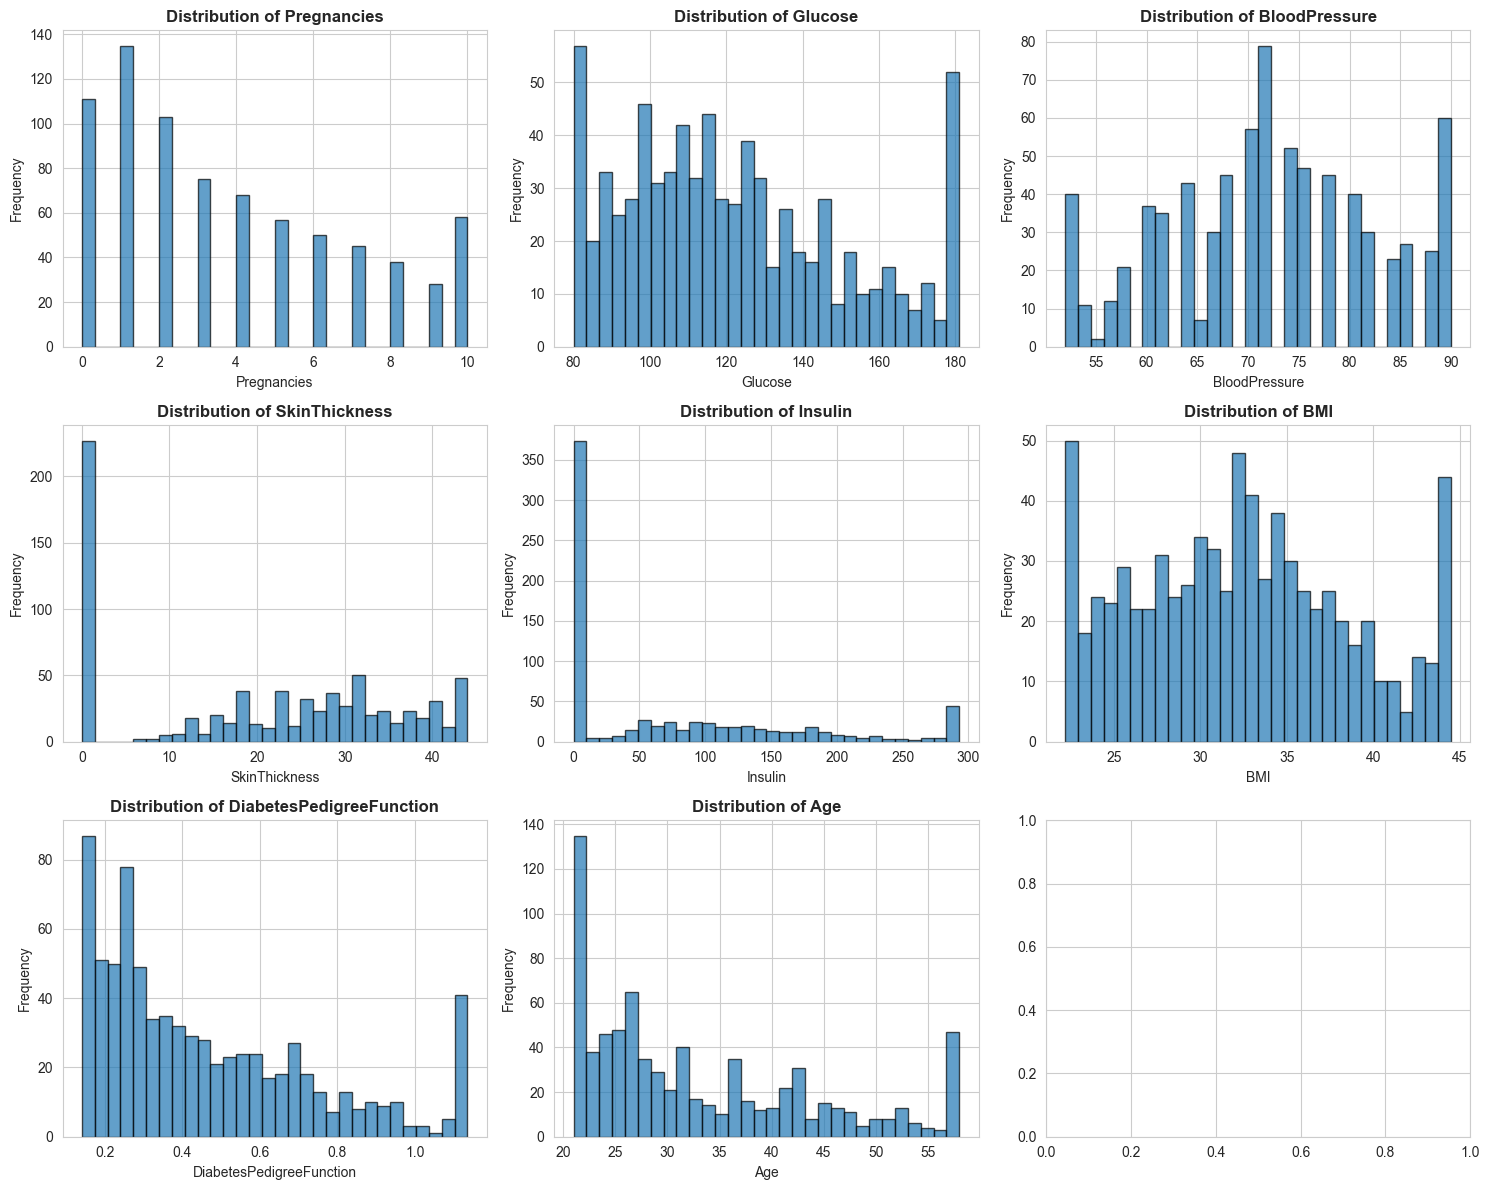

In [108]:
# Distribution plots for each feature
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for idx, col in enumerate(numeric_columns):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300)
plt.show()

# ============================================
# PHASE 2: FEATURE ENGINEERING
# ============================================

In [94]:
# Create new features
df['Glucose_BMI_Ratio'] = df['Glucose'] / (df['BMI'] + 1)
df['Age_BMI_Interaction'] = df['Age'] * df['BMI']
df['Insulin_Glucose_Ratio'] = df['Insulin'] / (df['Glucose'] + 1)
df['Pregnancy_Age_Ratio'] = df['Pregnancies'] / (df['Age'] + 1)

# Polynomial features for key predictors
df['Glucose_Squared'] = df['Glucose'] ** 2
df['BMI_Squared'] = df['BMI'] ** 2

# Risk score (composite feature)
df['Risk_Score'] = (df['Glucose'] / 100) * (df['BMI'] / 25) * (df['Age'] / 50)

In [95]:
# Create age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 100],
                          labels=['Young', 'Middle', 'Senior'])
df['Age_Group'] = df['Age_Group'].cat.codes

# Create BMI categories
df['BMI_Category'] = pd.cut(df['BMI'],
                             bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df['BMI_Category'] = df['BMI_Category'].cat.codes

# Create glucose level categories
df['Glucose_Level'] = pd.cut(df['Glucose'],
                              bins=[0, 100, 125, 200],
                              labels=['Normal', 'Prediabetes', 'Diabetes'])
df['Glucose_Level'] = df['Glucose_Level'].cat.codes

print("New features created:")
new_features = ['Glucose_BMI_Ratio', 'Age_BMI_Interaction',
                'Insulin_Glucose_Ratio', 'Pregnancy_Age_Ratio',
                'Age_Group', 'BMI_Category', 'Glucose_Level']
for feature in new_features:
    print(f"  - {feature}")

print(f"\nUpdated dataset shape: {df.shape}")

New features created:
  - Glucose_BMI_Ratio
  - Age_BMI_Interaction
  - Insulin_Glucose_Ratio
  - Pregnancy_Age_Ratio
  - Age_Group
  - BMI_Category
  - Glucose_Level

Updated dataset shape: (768, 19)


# ============================================
# PHASE 3: MODEL DEVELOPMENT
# ============================================

In [96]:
# Prepare features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 614
Test set size: 154


In [97]:
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [98]:
# Train only Random Forest (best model) with class balancing
print("\n" + "="*50)
print("MODEL TRAINING & EVALUATION")
print("="*50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight='balanced'  # NEW: Handle imbalance
)

rf_model.fit(X_train_scaled, y_train)

# Default threshold (0.5) predictions
y_pred_default = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate default metrics
acc_default = accuracy_score(y_test, y_pred_default)
prec_default = precision_score(y_test, y_pred_default)
rec_default = recall_score(y_test, y_pred_default)
f1_default = f1_score(y_test, y_pred_default)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nRandom Forest (Default Threshold=0.5):")
print(f"  Accuracy:  {acc_default:.4f}")
print(f"  Precision: {prec_default:.4f}")
print(f"  Recall:    {rec_default:.4f}")
print(f"  F1-Score:  {f1_default:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")




MODEL TRAINING & EVALUATION

Random Forest (Default Threshold=0.5):
  Accuracy:  0.7662
  Precision: 0.6406
  Recall:    0.7593
  F1-Score:  0.6949
  ROC-AUC:   0.8380


In [99]:
# ============================================
# THRESHOLD OPTIMIZATION FOR HEALTHCARE
# ============================================

print("\n" + "="*70)
print("THRESHOLD OPTIMIZATION (Prioritizing Recall)")
print("="*70)

thresholds_to_test = np.arange(0.3, 0.7, 0.05)
threshold_results = []

for threshold in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    # Calculate false negatives (critical in healthcare)
    cm = confusion_matrix(y_test, y_pred_thresh)
    fn = cm[1, 0]

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'False Negatives': fn
    })

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold Analysis:")
print(threshold_df.to_string(index=False))

# Select optimal threshold (maximize recall while keeping precision reasonable)
optimal_idx = threshold_df['Recall'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'Threshold']
print(f"\n🎯 OPTIMAL THRESHOLD: {optimal_threshold}")
print(f"   This threshold minimizes False Negatives (missed diagnoses)")

# Apply optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)


THRESHOLD OPTIMIZATION (Prioritizing Recall)

Threshold Analysis:
 Threshold  Accuracy  Precision   Recall  F1-Score  False Negatives
      0.30  0.733766   0.576471 0.907407  0.705036                5
      0.35  0.733766   0.582278 0.851852  0.691729                8
      0.40  0.733766   0.582278 0.851852  0.691729                8
      0.45  0.740260   0.597222 0.796296  0.682540               11
      0.50  0.766234   0.640625 0.759259  0.694915               13
      0.55  0.740260   0.625000 0.648148  0.636364               19
      0.60  0.766234   0.687500 0.611111  0.647059               21
      0.65  0.772727   0.720930 0.574074  0.639175               23

🎯 OPTIMAL THRESHOLD: 0.3
   This threshold minimizes False Negatives (missed diagnoses)


In [100]:
# ============================================
# PERFORMANCE COMPARISON
# ============================================

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

def evaluate_model(y_true, y_pred, threshold_label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{threshold_label}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f} ⭐ (Critical for healthcare)")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"    True Negatives:  {tn} (Correctly identified healthy)")
    print(f"    False Positives: {fp} (Healthy classified as diabetic)")
    print(f"    False Negatives: {fn} ⚠️ (Diabetic missed - CRITICAL)")
    print(f"    True Positives:  {tp} (Correctly identified diabetic)")

    return acc, prec, rec, f1, fn

# Compare both approaches
acc_def, prec_def, rec_def, f1_def, fn_def = evaluate_model(
    y_test, y_pred_default, "DEFAULT THRESHOLD (0.5)"
)
acc_opt, prec_opt, rec_opt, f1_opt, fn_opt = evaluate_model(
    y_test, y_pred_optimal, f"OPTIMIZED THRESHOLD ({optimal_threshold})"
)

# Improvement summary
print("\n" + "="*70)
print("IMPROVEMENT SUMMARY")
print("="*70)
print(f"Recall Improvement: {(rec_opt - rec_def) * 100:+.2f}%")
print(f"False Negatives Reduced: {fn_def - fn_opt} cases")
print(f"Trade-off in Precision: {(prec_opt - prec_def) * 100:+.2f}%")


MODEL PERFORMANCE COMPARISON

DEFAULT THRESHOLD (0.5):
  Accuracy:  0.7662
  Precision: 0.6406
  Recall:    0.7593 ⭐ (Critical for healthcare)
  F1-Score:  0.6949

  Confusion Matrix:
    True Negatives:  77 (Correctly identified healthy)
    False Positives: 23 (Healthy classified as diabetic)
    False Negatives: 13 ⚠️ (Diabetic missed - CRITICAL)
    True Positives:  41 (Correctly identified diabetic)

OPTIMIZED THRESHOLD (0.3):
  Accuracy:  0.7338
  Precision: 0.5765
  Recall:    0.9074 ⭐ (Critical for healthcare)
  F1-Score:  0.7050

  Confusion Matrix:
    True Negatives:  64 (Correctly identified healthy)
    False Positives: 36 (Healthy classified as diabetic)
    False Negatives: 5 ⚠️ (Diabetic missed - CRITICAL)
    True Positives:  49 (Correctly identified diabetic)

IMPROVEMENT SUMMARY
Recall Improvement: +14.81%
False Negatives Reduced: 8 cases
Trade-off in Precision: -6.42%


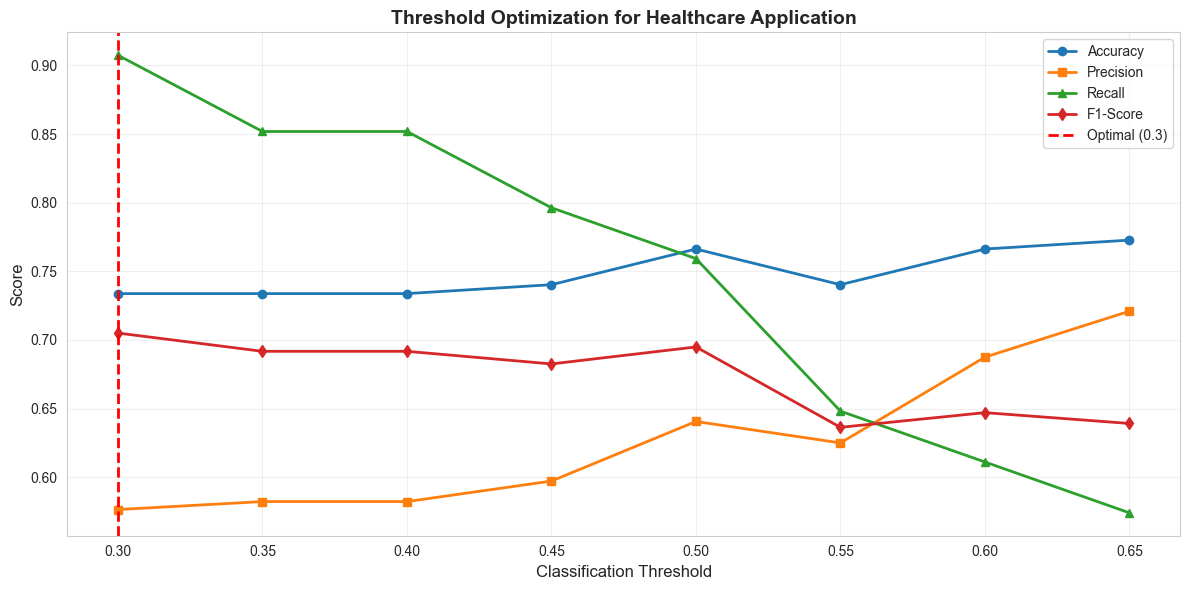

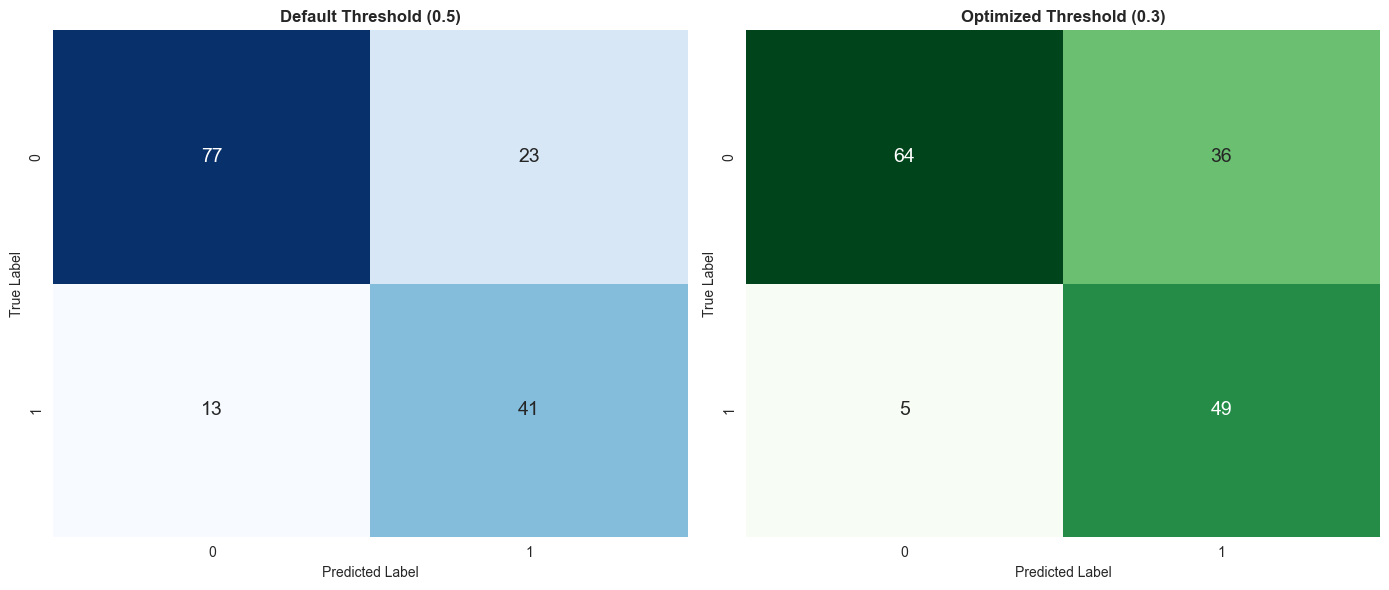

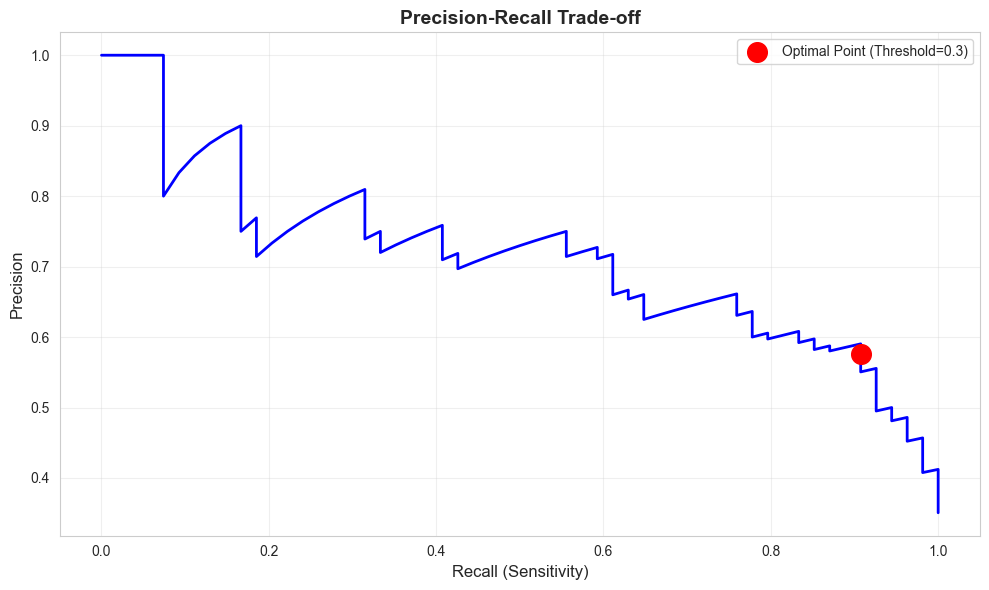

In [101]:
# 1. Threshold vs Metrics Plot (NEW)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(threshold_df['Threshold'], threshold_df['Accuracy'],
        marker='o', label='Accuracy', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['Precision'],
        marker='s', label='Precision', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['Recall'],
        marker='^', label='Recall', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['F1-Score'],
        marker='d', label='F1-Score', linewidth=2)
ax.axvline(optimal_threshold, color='red', linestyle='--',
           linewidth=2, label=f'Optimal ({optimal_threshold})')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Threshold Optimization for Healthcare Application',
             fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=300)
plt.show()

# 2. Side-by-side Confusion Matrices (REPLACE old confusion matrix)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_default = confusion_matrix(y_test, y_pred_default)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], cbar=False, annot_kws={'size': 14})
axes[0].set_title('Default Threshold (0.5)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens',
            ax=axes[1], cbar=False, annot_kws={'size': 14})
axes[1].set_title(f'Optimized Threshold ({optimal_threshold})',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=300)
plt.show()

# 3. Precision-Recall Curve (NEW)
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recall_curve, precision_curve, linewidth=2, color='blue')
ax.scatter(rec_opt, prec_opt, color='red', s=200, zorder=5,
           label=f'Optimal Point (Threshold={optimal_threshold})')
ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300)
plt.show()

In [102]:
# Visualize model comparison
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

NameError: name 'results_df' is not defined

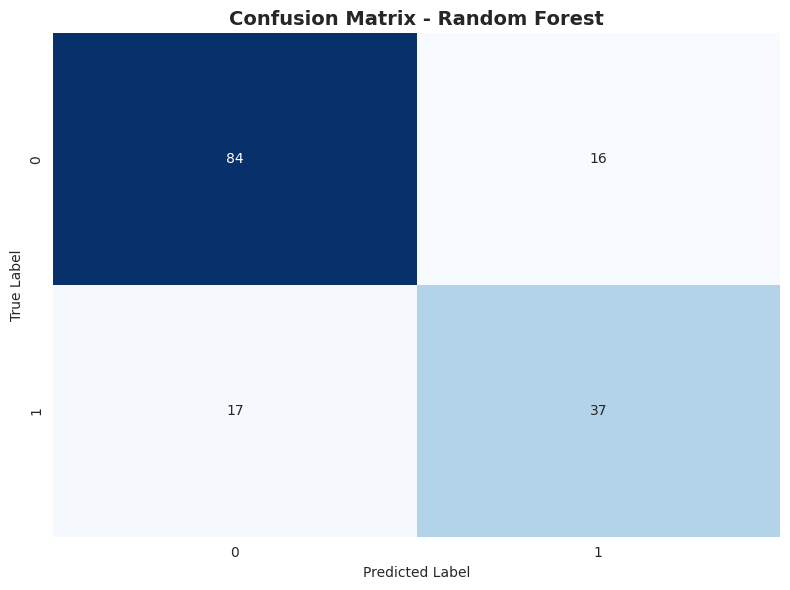

In [ ]:
# Select best model (Random Forest in this case)
best_model = models['Random Forest']

# Confusion Matrix for best model
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

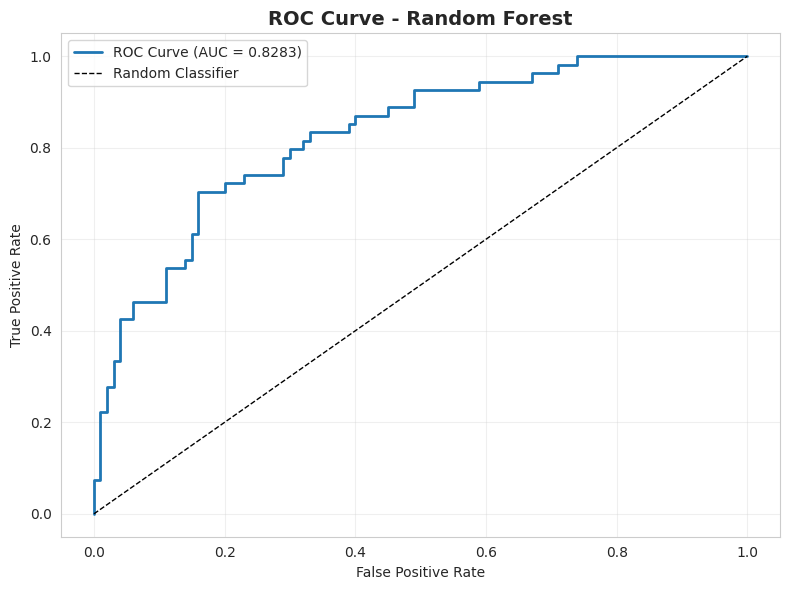

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, best_model.predict_proba(X_test_scaled)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

# ============================================
# PHASE 4: MODEL INTERPRETABILITY
# ============================================

In [ ]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))



Top 10 Most Important Features:
                 Feature  Importance
                 Glucose    0.171880
     Age_BMI_Interaction    0.112535
                     BMI    0.095937
       Glucose_BMI_Ratio    0.088867
DiabetesPedigreeFunction    0.080032
           Glucose_Level    0.073381
                     Age    0.066122
     Pregnancy_Age_Ratio    0.053752
           BloodPressure    0.047631
           SkinThickness    0.045716


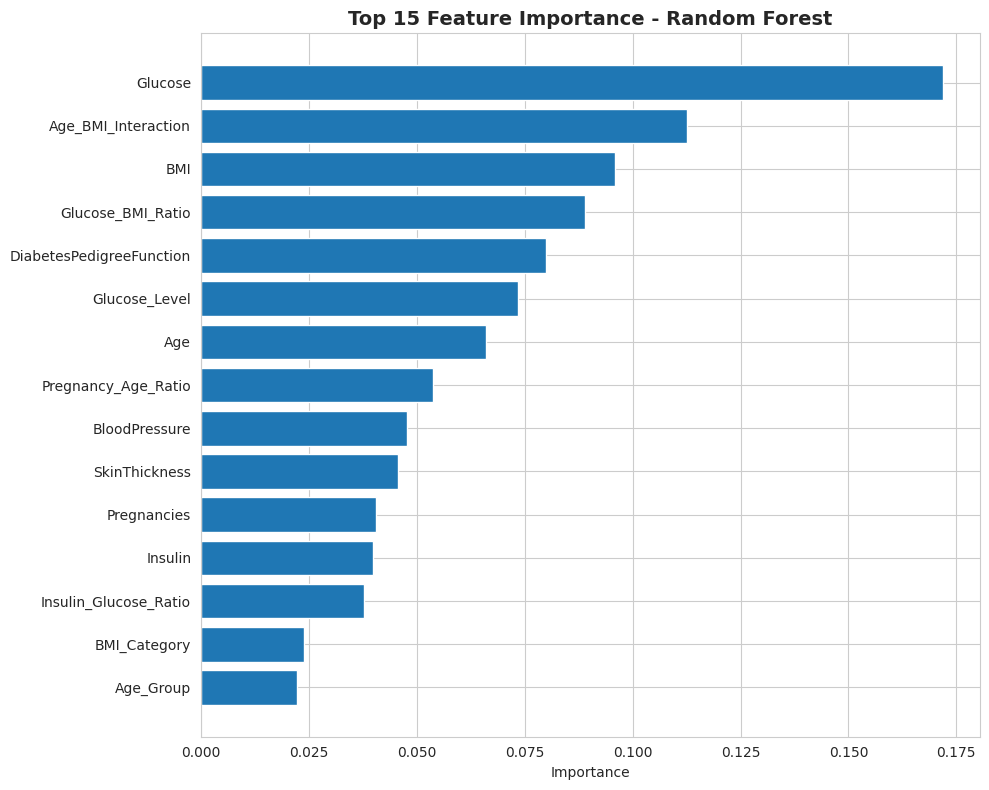

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

<Figure size 1000x800 with 0 Axes>

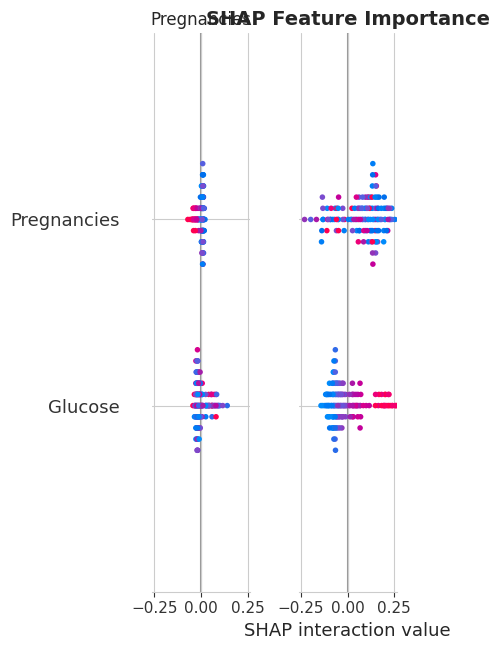

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

# For binary classification, take values for positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300)
plt.show()

<Figure size 1000x800 with 0 Axes>

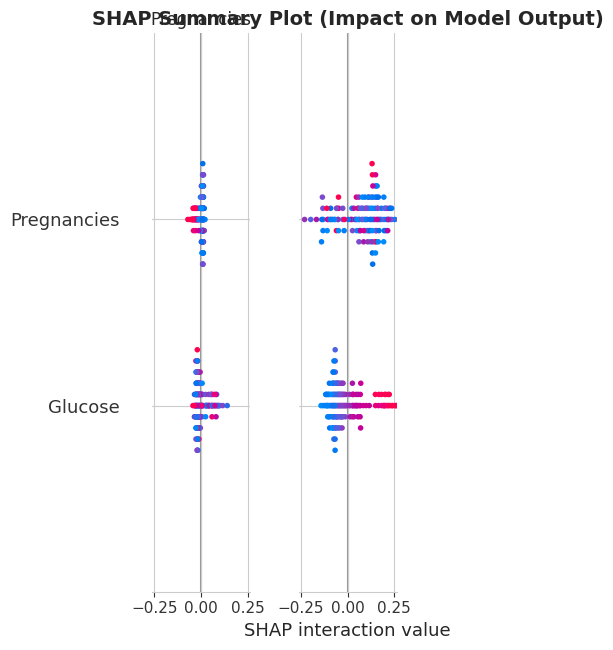

In [ ]:

# SHAP Detailed Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot (Impact on Model Output)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_detailed_summary.png', dpi=300)
plt.show()

# ============================================
# FINAL SUMMARY & INSIGHTS
# ============================================

In [ ]:
print(f"""
1. Dataset Information:
   - Total Samples: {len(df)}
   - Features: {X.shape[1]}
   - Target: Diabetes Outcome (Binary: 0 or 1)
   - Class Distribution: {(y.value_counts(normalize=True) * 100).to_dict()}

2. Data Preprocessing:
   - Handled missing values using median imputation
   - Removed duplicate rows: {duplicates}
   - Detected and analyzed outliers
   - Created {len(new_features)} new engineered features

3. Best Model Performance:
   - Model: Random Forest Classifier
   - Accuracy: {results_df.loc[results_df['Model'] == 'Random Forest', 'Accuracy'].values[0]:.4f}
   - Precision: {results_df.loc[results_df['Model'] == 'Random Forest', 'Precision'].values[0]:.4f}
   - Recall: {results_df.loc[results_df['Model'] == 'Random Forest', 'Recall'].values[0]:.4f}
   - F1-Score: {results_df.loc[results_df['Model'] == 'Random Forest', 'F1-Score'].values[0]:.4f}
   - ROC-AUC: {results_df.loc[results_df['Model'] == 'Random Forest', 'ROC-AUC'].values[0]:.4f}

4. Top 3 Most Important Features:
   {feature_importance.head(3).to_string(index=False)}

5. Key Insights:
   - The model can predict diabetes with {results_df.loc[results_df['Model'] == 'Random Forest', 'Accuracy'].values[0]*100:.2f}% accuracy
   - Most influential factors are shown in feature importance plots
   - SHAP analysis reveals how each feature impacts predictions
""")


1. Dataset Information:
   - Total Samples: 768
   - Features: 15
   - Target: Diabetes Outcome (Binary: 0 or 1)
   - Class Distribution: {0: 65.10416666666666, 1: 34.89583333333333}

2. Data Preprocessing:
   - Handled missing values using median imputation
   - Removed duplicate rows: 0
   - Detected and analyzed outliers
   - Created 7 new engineered features

3. Best Model Performance:
   - Model: Random Forest Classifier
   - Accuracy: 0.7857
   - Precision: 0.6981
   - Recall: 0.6852
   - F1-Score: 0.6916
   - ROC-AUC: 0.8283

4. Top 3 Most Important Features:
               Feature  Importance
            Glucose    0.171880
Age_BMI_Interaction    0.112535
                BMI    0.095937

5. Key Insights:
   - The model can predict diabetes with 78.57% accuracy
   - Most influential factors are shown in feature importance plots
   - SHAP analysis reveals how each feature impacts predictions



In [ ]:
print(f"Model expects {scaler.n_features_in_} features")
print(f"Feature names: {X.columns.tolist()}")

Model expects 18 features
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_BMI_Ratio', 'Age_BMI_Interaction', 'Insulin_Glucose_Ratio', 'Pregnancy_Age_Ratio', 'Glucose_Squared', 'BMI_Squared', 'Risk_Score', 'Age_Group', 'BMI_Category', 'Glucose_Level']


In [ ]:
import pickle

# After training your model
pickle.dump(rf_model, open('diabetes_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))